<a href="https://colab.research.google.com/github/whunotexplain/data_nba_players_analyze/blob/main/data_nba_players.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1)Library and color import

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#14141f',
    'axes.edgecolor':   '#2a2a3a',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'text.color':       '#eeeeee',
    'grid.color':       '#1e1e2e',
})

COLORS = ['#FFD700','#00B4D8','#57EE9A','#E63946','#C77DFF','#FF6B6B']

##2)Dataset

In [6]:
data = pd.read_csv('/content/nba_player_stats_2026.csv')


In [7]:
data.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,...,495,530,105,34,255,153,2143,2146,2.08,0.41
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,...,292,448,95,52,151,139,2117,2189,2.97,0.63
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,...,492,364,72,27,259,191,2038,1817,1.41,0.28
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,...,426,372,62,71,246,142,2026,1992,1.51,0.25
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,...,290,461,130,55,171,151,1980,1893,2.70,0.76


In [8]:
print(f"Shape = {data.shape}")

Shape = (582, 28)


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PLAYER_ID  582 non-null    int64  
 1   RANK       582 non-null    int64  
 2   PLAYER     582 non-null    object 
 3   TEAM_ID    582 non-null    int64  
 4   TEAM       582 non-null    object 
 5   GP         582 non-null    int64  
 6   MIN        582 non-null    int64  
 7   FGM        582 non-null    int64  
 8   FGA        582 non-null    int64  
 9   FG_PCT     582 non-null    float64
 10  FG3M       582 non-null    int64  
 11  FG3A       582 non-null    int64  
 12  FG3_PCT    582 non-null    float64
 13  FTM        582 non-null    int64  
 14  FTA        582 non-null    int64  
 15  FT_PCT     582 non-null    float64
 16  OREB       582 non-null    int64  
 17  DREB       582 non-null    int64  
 18  REB        582 non-null    int64  
 19  AST        582 non-null    int64  
 20  STL       

In [10]:
data.describe()

,PLAYER_ID,RANK,TEAM_ID,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
count,5.820000e+02,582.000000,5.820000e+02,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,...,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,1.476871e+06,291.182131,1.610613e+09,45.792096,1019.788660,177.365979,376.561856,0.461811,56.214777,156.305842,...,185.005155,113.027491,35.589347,20.458763,58.309278,83.969072,488.651203,563.673540,1.874296,0.726873
std,4.499530e+05,167.881426,8.755817e+00,24.937300,771.976925,164.245561,341.038339,0.102732,59.396653,155.982454,...,167.263286,121.804996,30.195315,24.895393,54.955127,61.869741,459.775808,501.760652,0.990909,0.544475
min,2.544000e+03,1.000000,1.610613e+09,1.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,0.000000,0.000000
25%,1.629018e+06,146.250000,1.610613e+09,23.000000,293.250000,38.000000,91.500000,0.417000,6.000000,21.500000,...,49.000000,21.250000,9.000000,4.000000,14.000000,27.000000,107.000000,133.250000,1.262500,0.400000
50%,1.630694e+06,291.000000,1.610613e+09,51.000000,940.500000,135.000000,292.000000,0.456000,38.000000,114.500000,...,148.500000,78.500000,30.000000,11.000000,42.500000,78.000000,363.500000,458.500000,1.725000,0.625000
75%,1.641838e+06,436.750000,1.610613e+09,67.750000,1609.250000,267.500000,579.250000,0.505750,89.750000,245.750000,...,275.750000,151.750000,55.000000,28.000000,85.000000,131.000000,759.000000,873.000000,2.320000,0.930000
max,1.643257e+06,579.000000,1.610613e+09,82.000000,2953.000000,736.000000,1543.000000,0.833000,273.000000,740.000000,...,892.000000,697.000000,150.000000,197.000000,259.000000,267.000000,2143.000000,2665.000000,6.360000,5.000000


In [11]:
data.dtypes.to_list()

[dtype('int64'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64')]

Добавил колонку для просмотра действий в среднем за игру

In [12]:
per_game_columns = ['PTS','REB','AST','STL','BLK','TOV','FGA','FGM','FG3A','FG3M','FTA','FTM']
for col in per_game_columns:
  data[col + "_PG"] = data[col] / data['GP']

##3.EDA

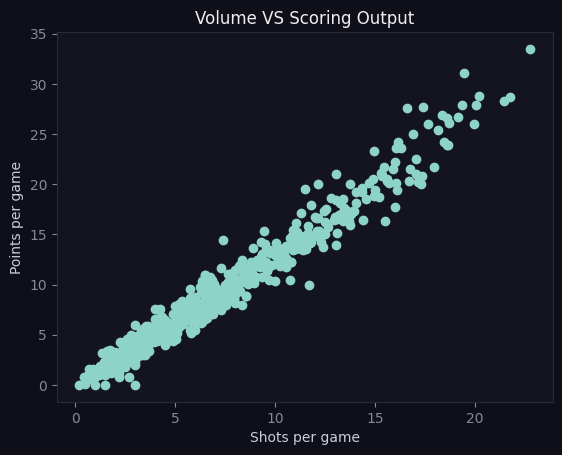

In [13]:
plt.scatter(data['FGA_PG'], data['PTS_PG'])
plt.xlabel("Shots per game")
plt.ylabel("Points per game")
plt.title("Volume VS Scoring Output")
plt.show()

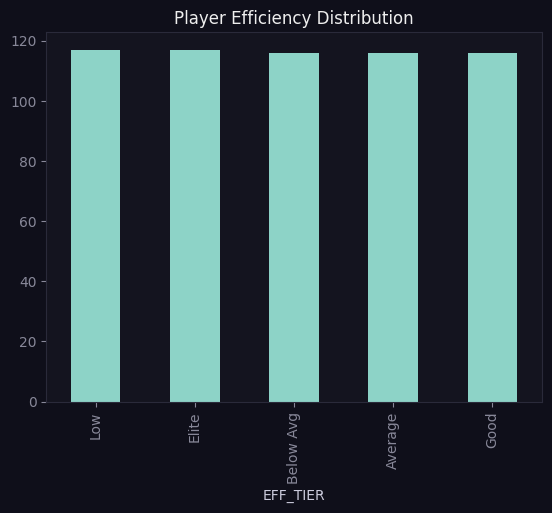

In [14]:
#Advanced ratio
data['PTS_per_FGA'] = data['PTS'] / data['FGA']
data["THREE_RATE"] = data["FG3A"] / data['FGA']
data['FTA_RATE'] = data['FTA'] / data['FGA']
data['EFF_PER_MIN'] = data['EFF'] / data['MIN']

data['EFF_TIER'] = pd.qcut(data['EFF'], q=5, labels = ['Low','Below Avg','Average','Good','Elite'])

data['EFF_TIER'].value_counts().plot(kind='bar')
plt.title("Player Efficiency Distribution")
plt.show()

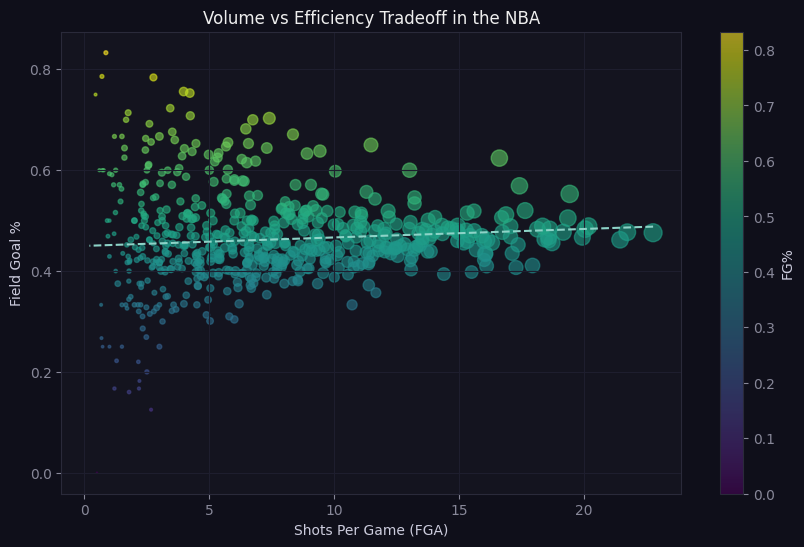

In [15]:
plt.figure(figsize=(10,6))


scatter= plt.scatter(
    data['FGA_PG'],
    data['FG_PCT'],
    s=data['PTS_PG']*5,
    c=data['FG_PCT'],
    alpha=0.6
)

# Trend line
z = np.polyfit(data['FGA_PG'], data['FG_PCT'], 1)
p = np.poly1d(z)
plt.plot(data['FGA_PG'], p(data['FGA_PG']), linestyle="--")

plt.xlabel("Shots Per Game (FGA)")
plt.ylabel("Field Goal %")
plt.title("Volume vs Efficiency Tradeoff in the NBA")

plt.colorbar(scatter, label="FG%")
plt.grid(True)

plt.show()

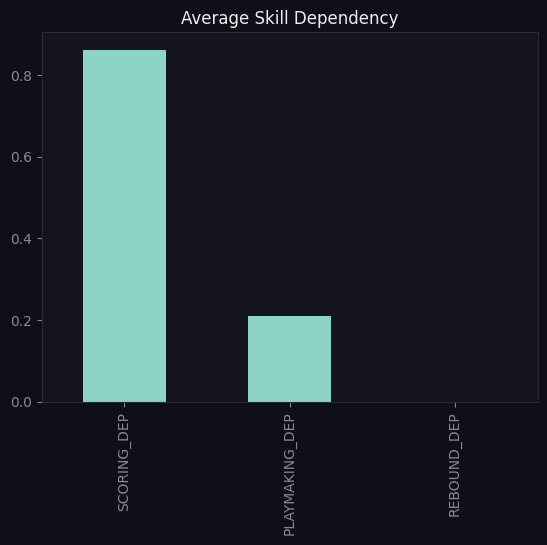

In [16]:
data['SCORING_DEP'] = data['PTS'] / data['EFF']
data['PLAYMAKING_DEP'] = data['AST'] / data['EFF']
data['REBOUND_DEP'] = data['REB'] / data['EFF']

data[['SCORING_DEP','PLAYMAKING_DEP','REBOUND_DEP']].mean().plot(kind='bar')
plt.title("Average Skill Dependency")
plt.show()

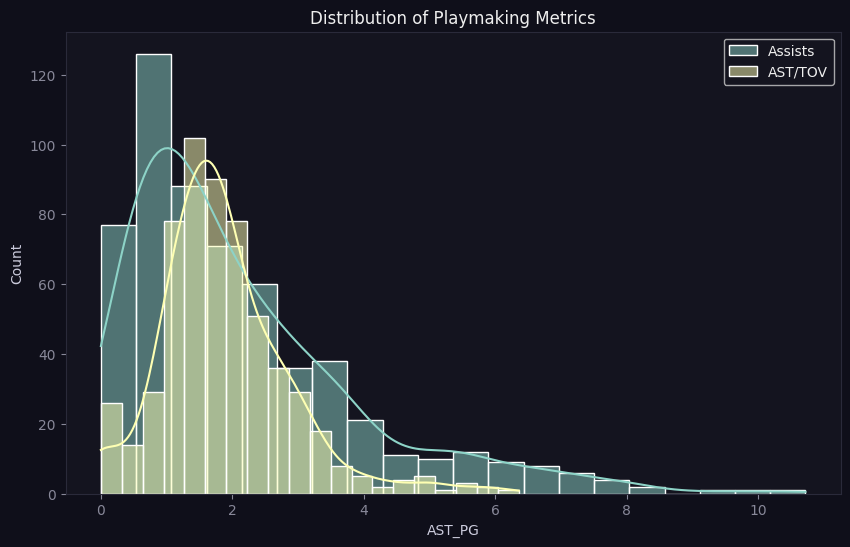

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data['AST_PG'],bins=20, kde=True, label="Assists")
sns.histplot(data['AST_TOV'], bins=20, kde=True, label="AST/TOV")

plt.legend()
plt.title("Distribution of Playmaking Metrics")
plt.show()

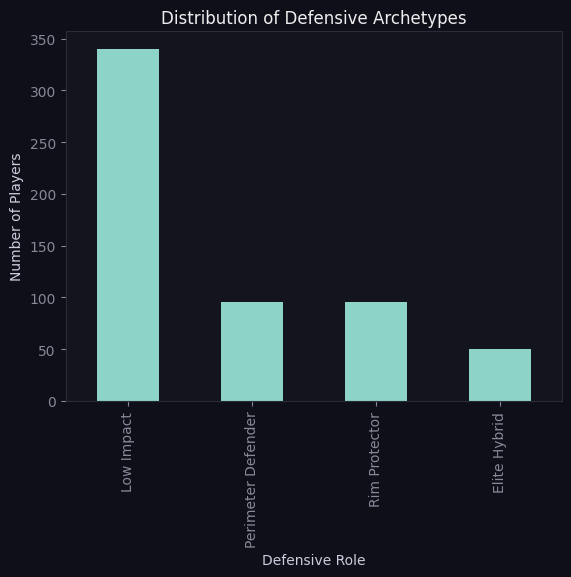

In [19]:
data['DEF_TYPE'] = 'Low Impact'


data.loc[(data['STL_PG'] > data['STL_PG'].quantile(0.75)), 'DEF_TYPE'] = 'Perimeter Defender'

data.loc[(data['BLK_PG'] > data['BLK_PG'].quantile(0.75), 'DEF_TYPE')] = 'Rim Protector'

data.loc[
    (data['STL_PG'] > data['STL_PG'].quantile(0.75)) &
    (data['BLK_PG'] > data['BLK_PG'].quantile(0.75)),
    'DEF_TYPE'
] = 'Elite Hybrid'

data['DEF_TYPE'].value_counts().plot(kind='bar')
plt.title("Distribution of Defensive Archetypes")
plt.xlabel("Defensive Role")
plt.ylabel('Number of Players')
plt.show()

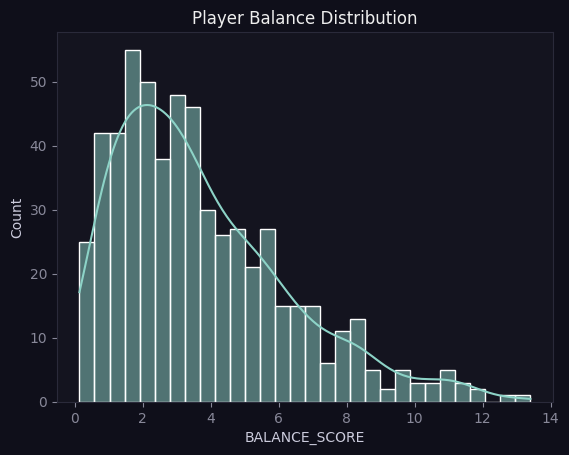

In [22]:
skills = data[['PTS_PG','AST_PG','REB_PG','STL_PG','BLK_PG']]
data['BALANCE_SCORE'] = skills.std(axis=1)


sns.histplot(data['BALANCE_SCORE'], bins=30, kde=True)
plt.title("Player Balance Distribution")
plt.show()

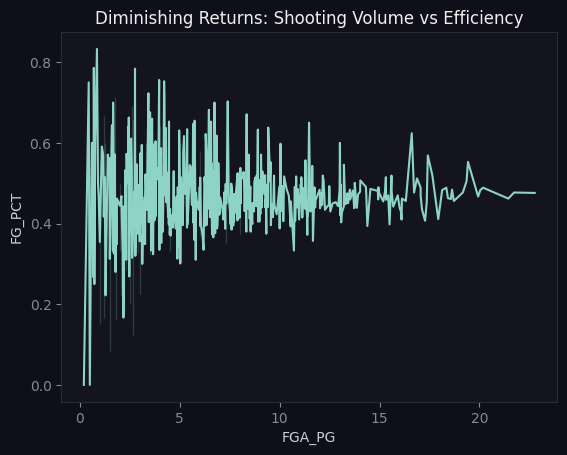

In [23]:
sns.lineplot(x='FGA_PG', y='FG_PCT', data=data)
plt.title("Diminishing Returns: Shooting Volume vs Efficiency")
plt.show()

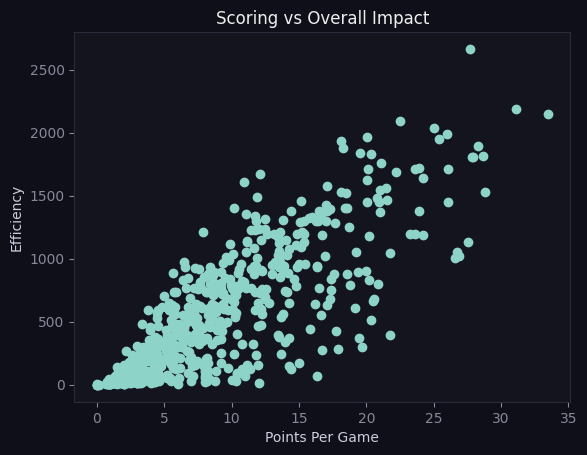

In [24]:
plt.scatter(data['PTS_PG'], data['EFF'])
plt.xlabel("Points Per Game")
plt.ylabel("Efficiency")
plt.title("Scoring vs Overall Impact")
plt.show()

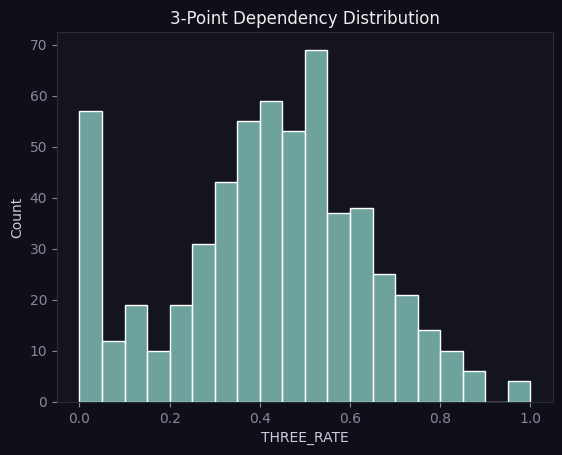

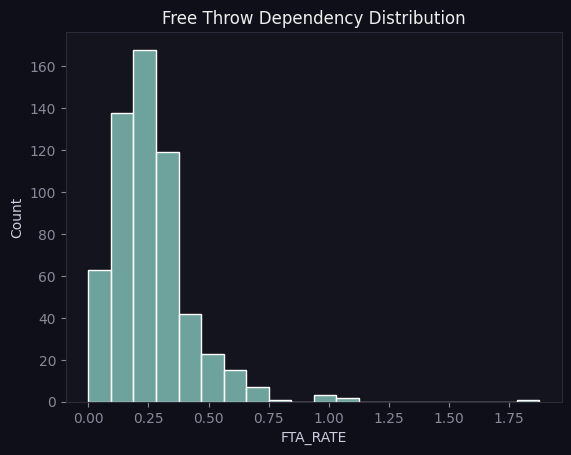

In [25]:
sns.histplot(data['THREE_RATE'], bins=20)
plt.title("3-Point Dependency Distribution")
plt.show()


sns.histplot(data['FTA_RATE'], bins=20)
plt.title("Free Throw Dependency Distribution")
plt.show()

In [26]:
data['PTS_PER_SHOT'] = data['PTS'] / data['FGA']

top_efficient = data.sort_values(by='EFF_PER_MIN', ascending=False).head(10)
top_efficient[['PLAYER', 'EFF_PER_MIN']]

,PLAYER,EFF_PER_MIN
9,Nikola Jokić,1.176600
18,Victor Wembanyama,1.092176
83,Giannis Antetokounmpo,1.091434
532,Norchad Omier,1.000000
1,Shai Gilgeous-Alexander,0.969013
0,Luka Dončić,0.937527
34,Jalen Duren,0.929150
206,Jonas Valančiūnas,0.870264
325,Ty Jerome,0.870206
8,Kawhi Leonard,0.867146


In [27]:
data['DECISION_SCORE'] = data['AST_TOV'] + data['STL_TOV']

data.sort_values(by='DECISION_SCORE', ascending=False)[['PLAYER','DECISION_SCORE']].head(10)

,PLAYER,DECISION_SCORE
304,Dean Wade,8.25
524,Chris Boucher,8.00
503,Taj Gibson,8.00
463,Chris Youngblood,8.00
561,Chris Mañon,8.00
456,Chaz Lanier,8.00
518,Kadary Richmond,8.00
373,Tyus Jones,7.84
525,TyTy Washington Jr.,7.67
549,Isaiah Stevens,7.50


In [28]:
inflated = data[
    (data['PTS_PG'] > 20) &
    (data['FG_PCT'] < 0.43) &
    (data['TOV_PG'] > data['TOV_PG'].mean())
]

inflated[['PLAYER','PTS_PG','FG_PCT','TOV_PG']]

,PLAYER,PTS_PG,FG_PCT,TOV_PG
29,LaMelo Ball,20.069444,0.407,2.805556
298,Jayson Tatum,21.750000,0.411,2.437500


##ML Application

In [29]:
from sklearn.preprocessing import StandardScaler

features = data[['PTS_PG','AST_PG','REB_PG','STL_PG','BLK_PG','FG_PCT']]
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

In [33]:
features = data[['PTS_PG','AST_PG','REB_PG','STL_PG','BLK_PG']]
scaler = StandardScaler()
X = scaler.fit_transform(features)

for k in [3,5,7]:
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(X)

  print(f"K={k}, Cluster counts: ", np.bincount(labels))

K=3, Cluster counts:  [144 347  91]
K=5, Cluster counts:  [185 211  40  65  81]
K=7, Cluster counts:  [ 63 176  26  57  47  72 141]


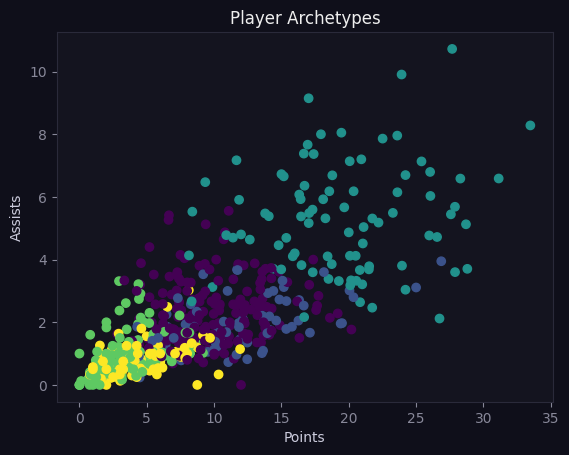

In [35]:
plt.scatter(data['PTS_PG'], data['AST_PG'], c=data['Cluster'])
plt.xlabel("Points")
plt.ylabel("Assists")
plt.title("Player Archetypes")
plt.show()

In [36]:
hidden_gems = data[
    (data['PTS_PG'] < 15) &
    (data['EFF'] > data['EFF'].quantile(0.75))
]

hidden_gems[['PLAYER','PTS_PG','EFF']]

,PLAYER,PTS_PG,EFF
52,Mikal Bridges,14.402439,1375
54,Jeremiah Fears,14.256098,1076
58,Brandin Podziemski,13.817073,1307
65,Brice Sensabaugh,14.880000,934
66,Reed Sheppard,13.536585,1122
...,...,...,...
221,Oso Ighodaro,6.475610,972
229,Ryan Kalkbrenner,7.550725,918
255,Luke Kornet,6.529412,936
262,Isaiah Hartenstein,9.191489,890


In [38]:
from sklearn.model_selection import train_test_split

features = data[['PTS_PG','AST_PG','REB_PG','STL_PG','BLK_PG','TOV_PG','FG_PCT']]
target = data['EFF']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("R2 Score:", r2_score(y_test, preds))

R2 Score: 0.7835653032022418


In [40]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

preds_rf = rf.predict(X_test)
print("R2 Score:", r2_score(y_test, preds_rf))

R2 Score: 0.7648118812863133


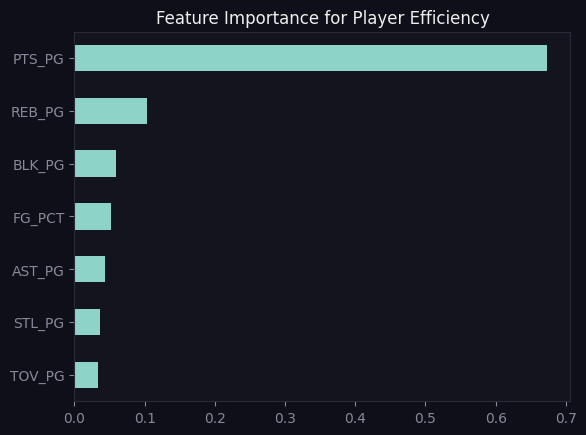

In [41]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance for Player Efficiency")
plt.show()